In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from metrics_analysis import ClassifierMetricsPlotter

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

#### Configuration

In [2]:
# ── Random state ──────────────────────────────────────────────────────────────────────
RANDOM_SEED   = 42

# ── Dataset ───────────────────────────────────────────────────────────────────────────
NUM_SAMPLES   = 20_000
FRAUD_RATE    = 0.05      # 5 % positive (fraud) rate
TRAIN_SIZE    = 0.80

# ── Default decision threshold ─────────────────────────────────────────────────────────
DEFAULT_THRESHOLD = 0.50

# ── Business cost parameters (euros) ─────────────────────────────────────────────────
FN_COST = 1_000   # cost of one missed fraud (false negative)
FP_COST = 100     # cost of one false alarm investigated (false positive, 1/10 × FN)

# ── Partial ROC-AUC capacity limit ────────────────────────────────────────────────────
MAX_FPR = 0.10    # we can review at most 10 % of legitimate transactions per day

## 1. Synthetic fraud dataset

We generate a dataset that mimics a payment fraud scenario:

* **20 000 transactions**, 5 % of which are fraudulent
* A mix of informative and noisy numeric features 
* Class imbalance is intentional — real fraud data is always skewed

In [ ]:
np.random.seed(RANDOM_SEED)
n_fraud    = int(NUM_SAMPLES * FRAUD_RATE)
n_legit    = NUM_SAMPLES - n_fraud

# ── Informative features (different distributions for fraud vs legit) ──────────────────
# transaction amount: fraud tends toward higher values
amount_legit = np.random.exponential(scale=150, size=n_legit)
amount_fraud = np.random.exponential(scale=600, size=n_fraud)

# ── Noise features (no predictive power) ──────────────────────────────────────────────
noise_legit = np.random.randn(n_legit, 4)
noise_fraud = np.random.randn(n_fraud, 4)

# ── Assemble ──────────────────────────────────────────────────────────────────────────
is_fraud = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)])

df = pd.DataFrame({
    "amount":           np.concatenate([amount_legit,           amount_fraud]),
    "noise_1":          np.concatenate([noise_legit[:, 0],      noise_fraud[:, 0]]),
    "noise_2":          np.concatenate([noise_legit[:, 1],      noise_fraud[:, 1]]),
    "noise_3":          np.concatenate([noise_legit[:, 2],      noise_fraud[:, 2]]),
    "noise_4":          np.concatenate([noise_legit[:, 3],      noise_fraud[:, 3]]),
    "is_fraud":         is_fraud,
})

# Shuffle so fraud rows are not all at the end
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(f"Fraud rate    : {df['is_fraud'].mean():.2%}")
df.head()

Dataset shape : (20000, 6)
Fraud rate    : 5.00%


,amount,noise_1,noise_2,noise_3,noise_4,is_fraud
0,413.951885,0.877943,1.252431,-0.462362,0.755616,0.0
1,123.564523,0.373463,-1.312600,-1.822741,0.571175,0.0
2,43.597598,1.024705,-1.279816,0.210536,-0.810201,0.0
3,134.819179,1.366159,-0.495509,1.206859,-0.699376,0.0
4,144.584793,0.110863,1.893318,-0.045530,1.736071,0.0


<Axes: >

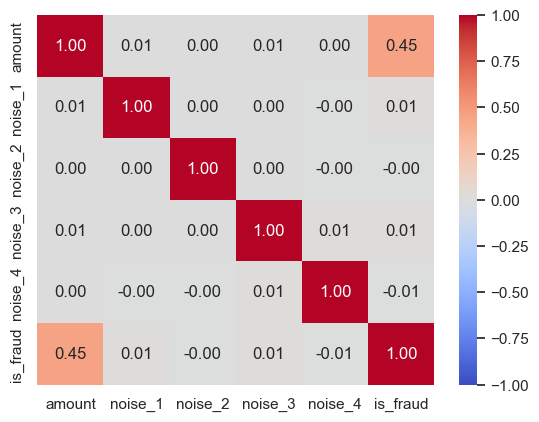

In [4]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

### Train / test split and model training

In [5]:
feature_cols = [c for c in df.columns if c != "is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols], df["is_fraud"],
    test_size=1 - TRAIN_SIZE,
    random_state=RANDOM_SEED,
    stratify=df["is_fraud"],
)

clf = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_SEED)
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)[:, 1]   # fraud probability scores

print(f"Train size : {len(X_train):,}  |  Test size : {len(X_test):,}")
print(f"Test fraud prevalence : {y_test.mean():.2%}")

Train size : 16,000  |  Test size : 4,000
Test fraud prevalence : 5.00%


---
## 2. What I knew first: precision, recall, and the threshold knob

Early in my career I evaluated binary classifiers with a single tool: the classification
report. Pick a threshold (the default `0.5` usually), read precision and recall, done.

The approach works — up to a point. The problem is that **the threshold is a choice, not a
property of the model**. If you only ever report numbers at `0.5`, you are reporting one
arbitrary operating point out of infinitely many.

              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98      3800
       Fraud       0.64      0.32      0.43       200

    accuracy                           0.96      4000
   macro avg       0.80      0.66      0.70      4000
weighted avg       0.95      0.96      0.95      4000



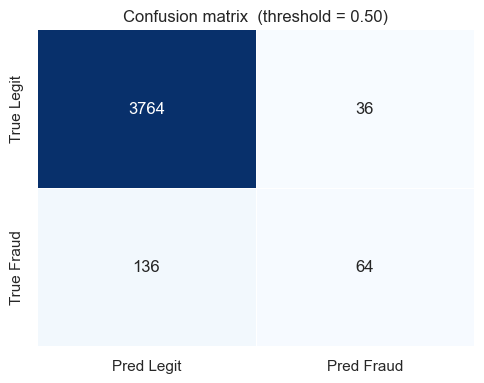

In [6]:
plotter = ClassifierMetricsPlotter()

print(classification_report(y_test, (y_proba >= DEFAULT_THRESHOLD).astype(int),
                             target_names=["Legit", "Fraud"]))

_ = plotter.plot_confusion_matrix(
    y_test.values, y_proba,
    threshold=DEFAULT_THRESHOLD,
    labels=("Legit", "Fraud"),
)

#### Reading the confusion matrix at threshold 0.5

| | Predicted legit | Predicted fraud |
|---|---|---|
| **True legit** | TN — correct dismissal | FP — false alarm (investigation cost) |
| **True fraud** | FN — **missed fraud** (highest cost) | TP — caught |

At the default 0.5 threshold the model is conservative: it only flags a transaction when
it is very confident, so **recall is low** — a lot of fraud slips through.
That might be fine for some use cases, terrible for fraud detection.

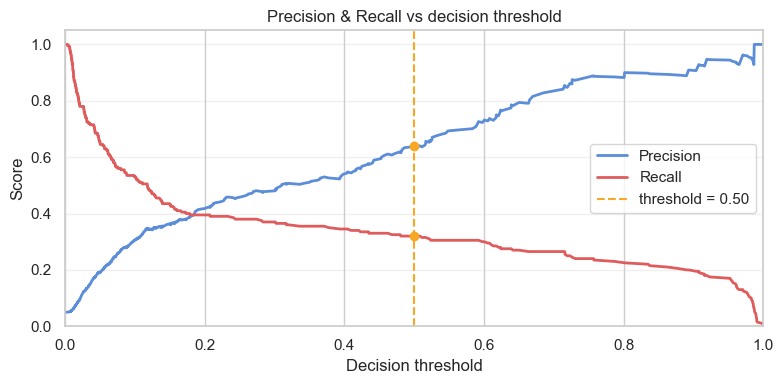

In [7]:
_ = plotter.plot_pr_vs_threshold(
    y_test.values, y_proba,
    highlight_threshold=DEFAULT_THRESHOLD,
)

#### The threshold trade-off

Moving the threshold **lower** increases recall (catch more fraud) but tanks precision
(more false alarms). Moving it **higher** does the opposite.

This is why reporting a single precision/recall pair is incomplete — **the model's
behaviour across all thresholds is the information you need**, not one point on that curve.

---
## 3. The upgrade: ROC AUC and PR AUC

The key insight is to evaluate the **model's discrimination power across all thresholds at
once** rather than locking in one operating point.

**ROC AUC** — area under the Receiver Operating Characteristic curve
: Probability that the model ranks a random fraud case higher than a random legitimate
one. A perfect model scores 1.0; random chance scores 0.5. It is interpretable but
can be **misleading on highly imbalanced data** because TN dominates the denominator.

**PR AUC** (average precision) — area under the Precision-Recall curve

: Directly measures the quality of the positive-class ranking, making it more sensitive
to how well the model separates the (rare) fraud cases. A random classifier scores
at the prevalence rate (5 % here); a perfect model scores 1.0.

ROC AUC  : 0.8023
PR  AUC  : 0.4397


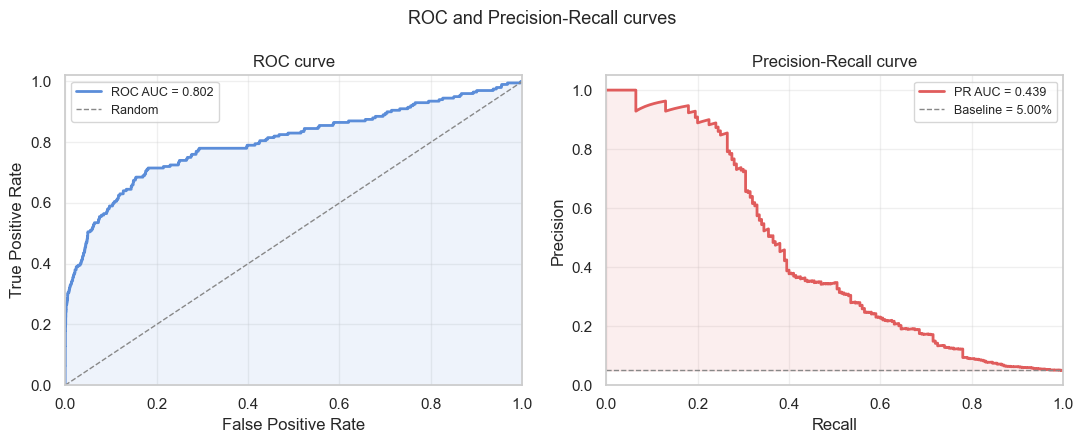

In [8]:
# Side-by-side overview
_ = plotter.plot_roc_and_pr(y_test.values, y_proba)

print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR  AUC  : {average_precision_score(y_test, y_proba):.4f}")

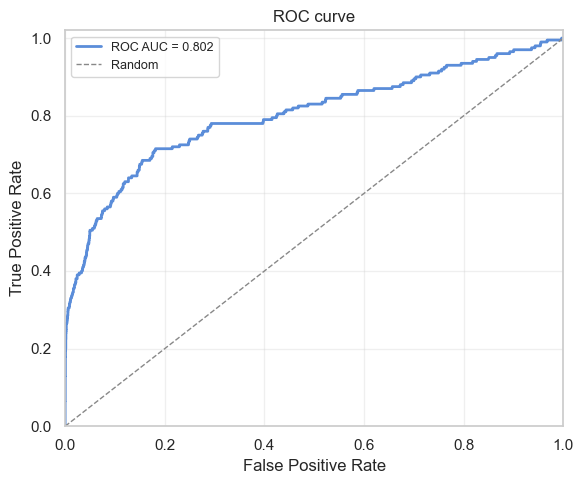

In [9]:
# ROC curve on its own — useful when you want to annotate a specific operating point
_ = plotter.plot_roc_curve(y_test.values, y_proba)

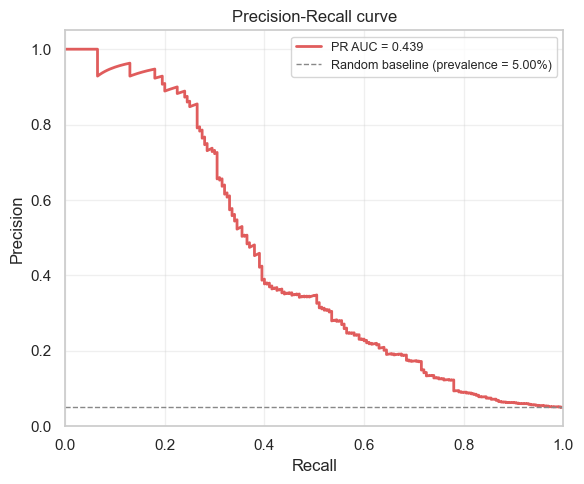

In [10]:
# PR curve on its own — primary metric for imbalanced fraud data
_ = plotter.plot_pr_curve(y_test.values, y_proba)

#### When to use which

| Metric | Use when … | Watch out for … |
|---|---|---|
| **ROC AUC** | Classes are roughly balanced; you care about ranking quality overall | Inflated by many true negatives in imbalanced datasets |
| **PR AUC** | Positive class is rare and precision matters (fraud, medical diagnosis) | Sensitive to prevalence — compare models on the same dataset |

For fraud detection, **PR AUC is the primary metric**. A model can achieve ROC AUC > 0.95
while still being useless at catching the rare positives.

---
## 4. Translating errors into euros: the cost of FP and FN

AUC metrics are dimensionless ranking scores — they do not tell you what the optimal
operating threshold is for *your* business. For that you need to attach costs.

In a fraud scenario the asymmetry is extreme:
* A **false negative** (missed fraud) means the bank absorbs the full transaction loss.
  Let's call this **1,000 € per incident**.
* A **false positive** (false alarm) triggers a manual review or blocks the customer.
  Cost: investigation time + friction = roughly **100 € per incident** (one tenth).

The optimal threshold is the one that **minimises the expected total cost**.

Cost-optimal threshold : 0.099

Classification report at cost-optimal threshold (0.10):
              precision    recall  f1-score   support

       Legit       0.97      0.94      0.95      3800
       Fraud       0.30      0.54      0.39       200

    accuracy                           0.92      4000
   macro avg       0.64      0.74      0.67      4000
weighted avg       0.94      0.92      0.93      4000



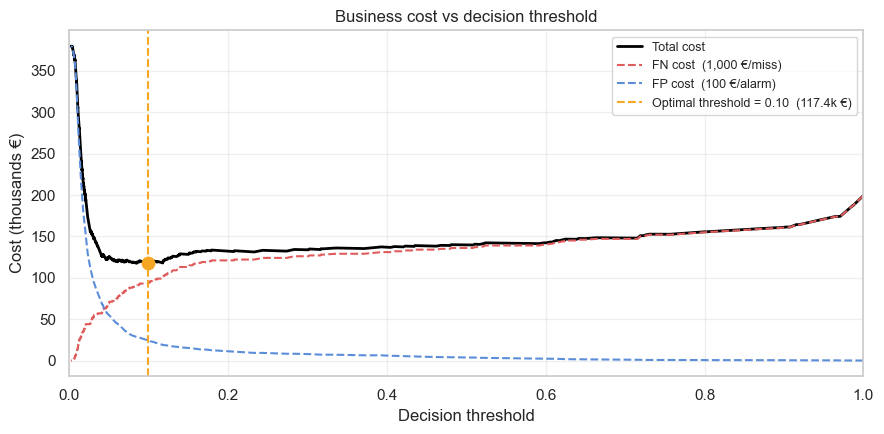

In [11]:
fig, best_threshold = plotter.plot_cost_curve(
    y_test.values, y_proba,
    fn_cost=FN_COST,
    fp_cost=FP_COST,
)

print(f"Cost-optimal threshold : {best_threshold:.3f}")
print()

# Show the confusion matrix at the cost-optimal threshold
print(f"Classification report at cost-optimal threshold ({best_threshold:.2f}):")
print(classification_report(y_test, (y_proba >= best_threshold).astype(int),
                             target_names=["Legit", "Fraud"]))

#### Decision: use the cost-optimal threshold, not 0.5

The cost curve makes explicit the trade-off that was hidden in the precision/recall chart.
At the optimal threshold:
* Recall is higher — we catch more fraud, reducing the most expensive error
* Precision drops — we generate more false alarms, but at a much lower unit cost

> **Rule of thumb:** if FN cost >> FP cost, your threshold should be well below 0.5.
> The exact value depends on the ratio `FP_COST / FN_COST`.

---
## 5. When you can only review the top N %: Partial ROC AUC

Both ROC AUC and cost curves assume you can act on **all** alerts the model produces.
In practice, fraud operations teams have **finite capacity**: say they can review
at most 200 alerts per day out of 10 000 daily transactions (= 2 % of the population,
or equivalently a fixed FPR budget).

In this regime the question is not "what is the best operating point?" but
**"how good is the model in the top-N region where we will actually operate?"**

**Partial ROC AUC** measures the area under the ROC curve restricted to a maximum
False Positive Rate (`max_fpr`). It focuses evaluation on the part of the curve
that corresponds to your operational capacity.

#### How to determine `max_fpr`

The capacity limit translates to a maximum False Positive Rate. Starting from `FPR = FP / N_neg`:

**Capacity as absolute count** `C` (reviews per day):

```
max_fpr = C / N_neg
        = daily_review_capacity / (total_daily_transactions × (1 − fraud_rate))
```

**Capacity as a flagging rate** `k` (fraction of all transactions alerted):

```
max_fpr (upper bound) = k / (1 − p)
```

Both are conservative upper bounds — they assume none of the `C` alerts are true positives.
The actual FPR will always be ≤ this value. This is the number you pass to sklearn.

There is also a **lower bound** — the FPR if the model is perfect (all fraud ranked first):

```
min_fpr (lower bound) = (k − p) / (1 − p)     [valid when k ≥ p]
```

If this returns negative, your capacity is below the fraud rate — you cannot catch all
fraud even at perfect precision.

In our dataset: `MAX_FPR = 0.10` (10 % flagging rate, p = 5 %) →
`upper = 0.10 / 0.95 ≈ 0.105`, `lower = 0.05 / 0.95 ≈ 0.053`.

Full ROC AUC            : 0.8023
Partial ROC AUC (≤10%) : 0.7156

Recall at FPR = 10% (capacity limit) : 59.00%


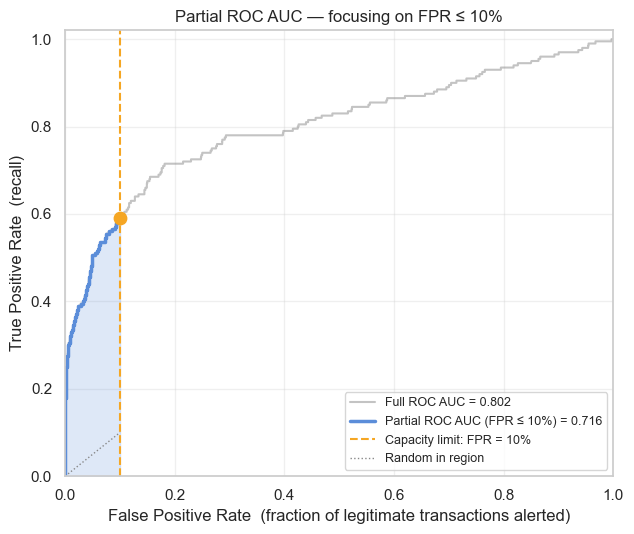

In [12]:
_ = plotter.plot_partial_roc(y_test.values, y_proba, max_fpr=MAX_FPR)

full_auc    = roc_auc_score(y_test, y_proba)
partial_auc = roc_auc_score(y_test, y_proba, max_fpr=MAX_FPR)

print(f"Full ROC AUC            : {full_auc:.4f}")
print(f"Partial ROC AUC (≤{MAX_FPR:.0%}) : {partial_auc:.4f}")
print()

# What recall do we get at exactly max_fpr?
from sklearn.metrics import roc_curve as _roc_curve
fpr, tpr, _ = _roc_curve(y_test, y_proba)
recall_at_capacity = np.interp(MAX_FPR, fpr, tpr)
print(f"Recall at FPR = {MAX_FPR:.0%} (capacity limit) : {recall_at_capacity:.2%}")

#### Decision: optimise partial AUC when capacity is constrained

| Metric | What it tells you | When to use it |
|---|---|---|
| **ROC AUC** | Overall ranking quality | Model selection with no ops constraint |
| **PR AUC** | Precision-recall trade-off for rare positives | When precision and recall both matter across thresholds |
| **Partial ROC AUC** | Ranking quality in the high-precision, low-FPR region | When your team can only action a fixed top-N alert list |

When comparing two models with similar full ROC AUC, **partial AUC can reveal which
one is actually better in the operating region you care about**. This is especially
important when capacity constraints are tighter than the average model performance
would suggest.

> **Workflow:**
> 1. Compute `max_fpr` from team capacity
> 2. Compare models on partial AUC at that `max_fpr`
> 3. The winner in the constrained region is the model to deploy — even if its full AUC is lower